In [1]:
# ==========================================================
# MACHINE LEARNING
# Phase 7.4 : Model Interpretation & Diagnostics
# ==========================================================

import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# PROJECT SETUP
# ==========================================================

project_root = r"D:\AI-Powered-Customer-Retention-Intelligence-Platform"

os.chdir(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:")
print(os.getcwd())

Project Root:
D:\AI-Powered-Customer-Retention-Intelligence-Platform


In [3]:
# ==========================================================
# LOAD MODELING DATA
# ==========================================================

model_path = "data/processed/customer_retention_model_data.csv"

model_data = pd.read_csv(model_path)

print("=" * 60)
print("MODEL DATASET")
print("=" * 60)

print("Shape:", model_data.shape)

print("\nColumns:")
print(model_data.columns.tolist())

MODEL DATASET
Shape: (96096, 10)

Columns:
['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'average_review_score', 'preferred_payment_method', 'average_order_value', 'customer_lifetime_value', 'Customer_Risk', 'churn_label']


In [4]:
# ==========================================================
# FEATURES AND TARGET
# ==========================================================

feature_columns = [
    "Frequency",
    "Monetary",
    "average_review_score",
    "preferred_payment_method",
    "average_order_value"
]

target_column = "churn_label"

X = model_data[feature_columns].copy()
y = model_data[target_column].copy()

numeric_features = [
    "Frequency",
    "Monetary",
    "average_review_score",
    "average_order_value"
]

categorical_features = [
    "preferred_payment_method"
]

print("Features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Features:
['Frequency', 'Monetary', 'average_review_score', 'preferred_payment_method', 'average_order_value']

Target:
churn_label


In [5]:
# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

target_counts = y.value_counts().sort_index()

target_percentages = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index = [
    "Active / Retained",
    "Churn-Risk"
]

print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print(target_summary)

TARGET DISTRIBUTION
                   Count  Percentage
Active / Retained  27744       28.87
Churn-Risk         68352       71.13


In [6]:
# ==========================================================
# FEATURE SUMMARY BY TARGET
# ==========================================================

numeric_summary = (
    model_data
    .groupby("churn_label")[numeric_features]
    .mean()
    .round(2)
)

numeric_summary.index = [
    "Active / Retained",
    "Churn-Risk"
]

print("=" * 60)
print("NUMERIC FEATURE MEANS BY TARGET")
print("=" * 60)

print(numeric_summary)

NUMERIC FEATURE MEANS BY TARGET
                   Frequency  Monetary  average_review_score  \
Active / Retained       1.04    171.10                  4.24   
Churn-Risk              1.03    164.76                  4.02   

                   average_order_value  
Active / Retained               164.71  
Churn-Risk                      160.06  


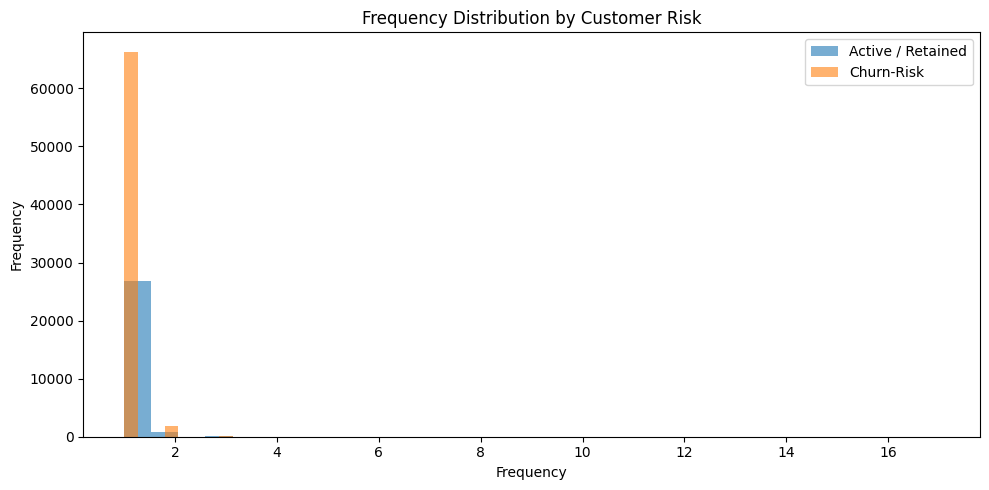

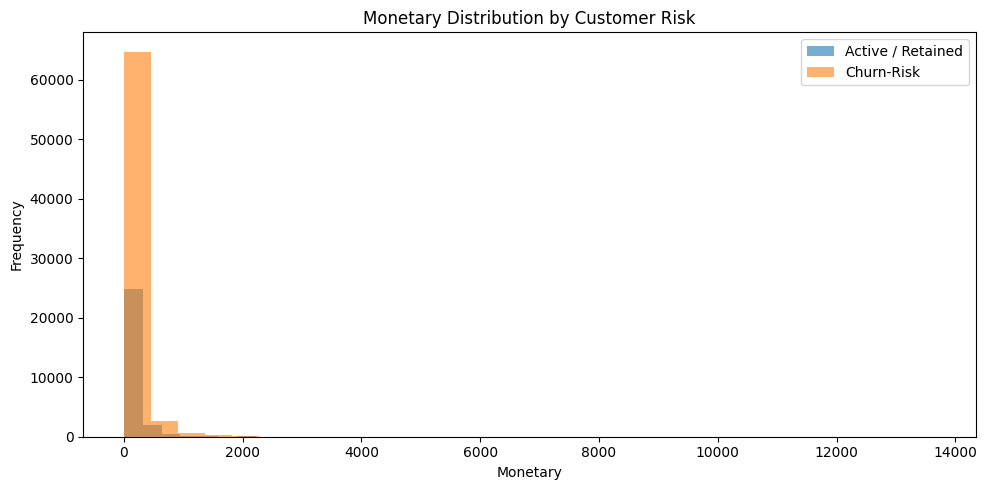

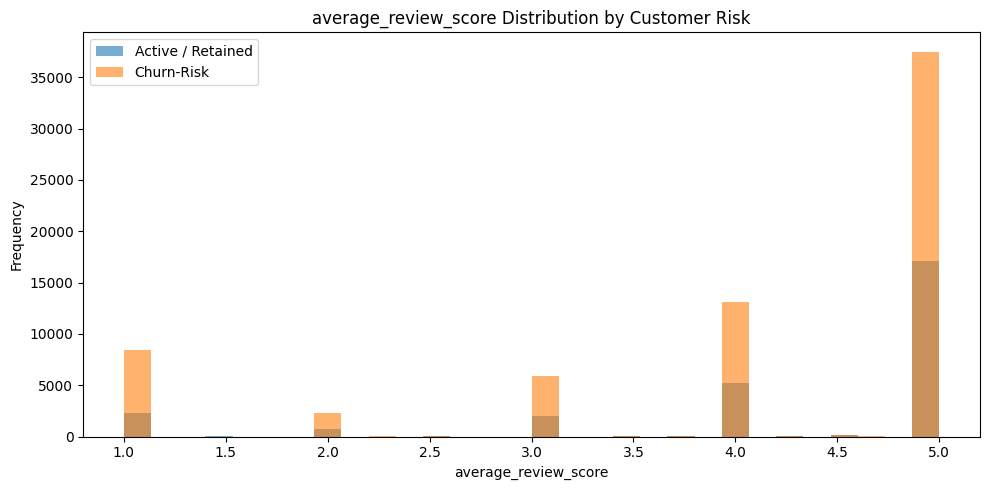

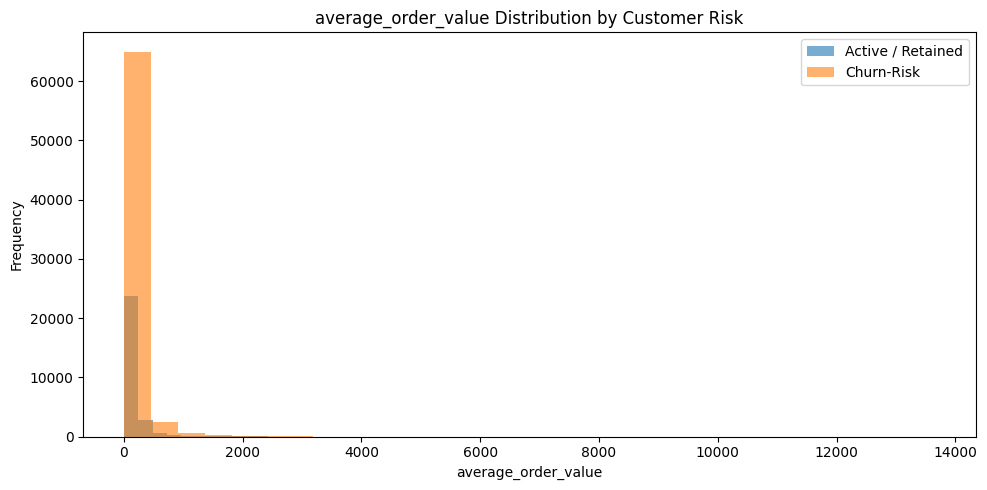

In [7]:
# ==========================================================
# FEATURE DISTRIBUTIONS BY TARGET
# ==========================================================

for feature in numeric_features:

    plt.figure(figsize=(10, 5))

    model_data[
        model_data["churn_label"] == 0
    ][feature].plot(
        kind="hist",
        bins=30,
        alpha=0.6,
        label="Active / Retained"
    )

    model_data[
        model_data["churn_label"] == 1
    ][feature].plot(
        kind="hist",
        bins=30,
        alpha=0.6,
        label="Churn-Risk"
    )

    plt.title(
        f"{feature} Distribution by Customer Risk"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [8]:
# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", gradient_boosting)
    ]
)

print("Gradient Boosting pipeline created.")

Gradient Boosting pipeline created.


In [9]:
# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

gb_pipeline.fit(
    X_train,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [10]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

classifier = gb_pipeline.named_steps["classifier"]

importance_values = classifier.feature_importances_

feature_names = (
    numeric_features +
    list(
        gb_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance_df)

FEATURE IMPORTANCE
                                Feature  Importance
0                              Monetary    0.367745
1                   average_order_value    0.327486
2                  average_review_score    0.165261
3   preferred_payment_method_debit_card    0.112235
4  preferred_payment_method_credit_card    0.013310
5       preferred_payment_method_boleto    0.006347
6                             Frequency    0.005509
7      preferred_payment_method_voucher    0.002106
8  preferred_payment_method_not_defined    0.000000


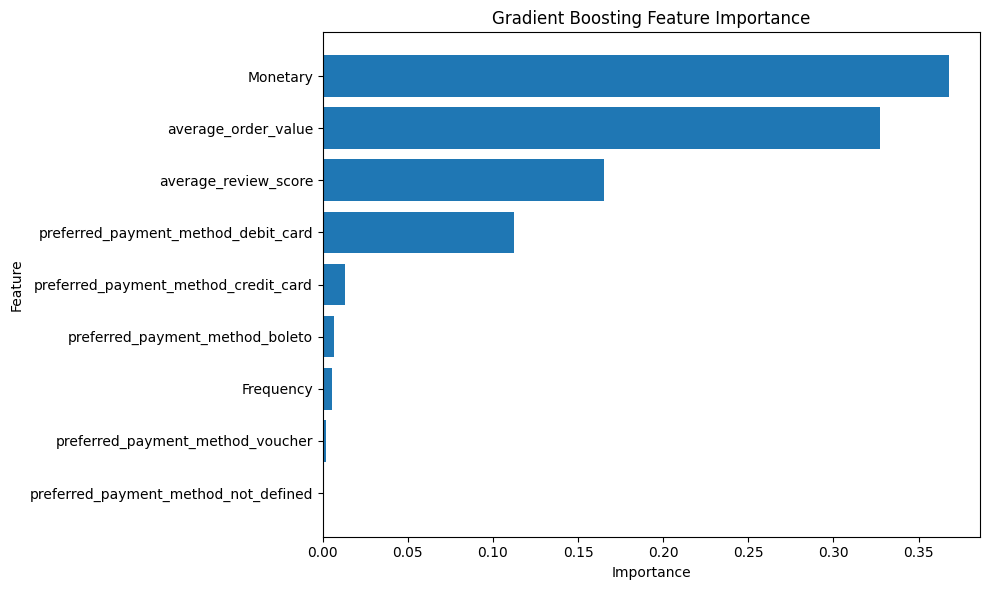

In [11]:
# ==========================================================
# FEATURE IMPORTANCE CHART
# ==========================================================

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Gradient Boosting Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [12]:
# ==========================================================
# PREDICTION PROBABILITIES
# ==========================================================

y_probability = gb_pipeline.predict_proba(
    X_test
)[:, 1]

probability_summary = pd.Series(
    y_probability
).describe()

print("=" * 60)
print("PREDICTION PROBABILITY SUMMARY")
print("=" * 60)

print(probability_summary)

PREDICTION PROBABILITY SUMMARY
count    19220.000000
mean         0.711548
std          0.053075
min          0.092048
25%          0.683347
50%          0.707340
75%          0.739073
max          0.899100
dtype: float64


In [13]:
# ==========================================================
# PRECISION-RECALL ANALYSIS
# ==========================================================

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)

pr_auc = average_precision_score(
    y_test,
    y_probability
)

print("=" * 60)
print("PRECISION-RECALL ANALYSIS")
print("=" * 60)

print("Average Precision / PR-AUC:", round(pr_auc, 4))

PRECISION-RECALL ANALYSIS
Average Precision / PR-AUC: 0.777


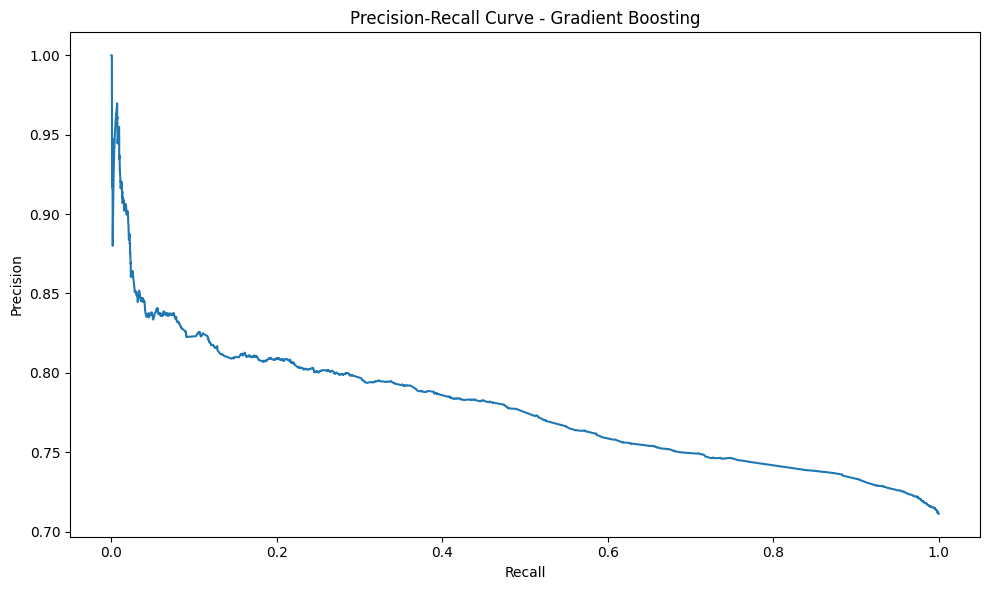

In [14]:
# ==========================================================
# PRECISION-RECALL CURVE
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Gradient Boosting"
)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# THRESHOLD ANALYSIS
# ==========================================================

thresholds_to_test = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds_to_test:

    y_threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(
            precision_score(
                y_test,
                y_threshold_pred,
                zero_division=0
            ),
            4
        ),
        "Recall": round(
            recall_score(
                y_test,
                y_threshold_pred,
                zero_division=0
            ),
            4
        ),
        "F1_Score": round(
            f1_score(
                y_test,
                y_threshold_pred,
                zero_division=0
            ),
            4
        ),
        "Predicted_Churn_Risk": int(
            y_threshold_pred.sum()
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("=" * 60)
print("THRESHOLD ANALYSIS")
print("=" * 60)

print(threshold_df)

THRESHOLD ANALYSIS
   Threshold  Precision  Recall  F1_Score  Predicted_Churn_Risk
0        0.3     0.7117  0.9996    0.8314                 19200
1        0.4     0.7121  0.9990    0.8315                 19180
2        0.5     0.7149  0.9941    0.8317                 19010
3        0.6     0.7182  0.9832    0.8300                 18716
4        0.7     0.7542  0.6488    0.6975                 11761
5        0.8     0.8519  0.0336    0.0647                   540


In [16]:
# ==========================================================
# DIAGNOSTIC SUMMARY
# ==========================================================

baseline_predictions = gb_pipeline.predict(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        baseline_predictions
    ),
    "Precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_probability
    ),
    "PR_AUC": average_precision_score(
        y_test,
        y_probability
    )
}

print("=" * 60)
print("GRADIENT BOOSTING DIAGNOSTIC SUMMARY")
print("=" * 60)

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

GRADIENT BOOSTING DIAGNOSTIC SUMMARY
Accuracy: 0.7139
Precision: 0.7149
Recall: 0.9941
F1: 0.8317
ROC_AUC: 0.6001
PR_AUC: 0.7770


In [17]:
# ==========================================================
# CUSTOMER-LEVEL EXPLAINABILITY
# SHAP ANALYSIS
# ==========================================================

import shap

print("SHAP imported successfully.")
print("SHAP version:", shap.__version__)

SHAP imported successfully.
SHAP version: 0.52.0


In [18]:
# ==========================================================
# PREPARE DATA FOR SHAP
# ==========================================================

# Extract preprocessing component
preprocessor_fitted = (
    gb_pipeline.named_steps["preprocessor"]
)

# Transform test data
X_test_transformed = (
    preprocessor_fitted.transform(X_test)
)

# Get transformed feature names
transformed_feature_names = (
    numeric_features
    +
    list(
        preprocessor_fitted
        .named_transformers_["categorical"]
        .named_steps["encoder"]
        .get_feature_names_out(
            categorical_features
        )
    )
)

print("Transformed Shape:")
print(X_test_transformed.shape)

print("\nNumber of Feature Names:")
print(len(transformed_feature_names))

Transformed Shape:
(19220, 9)

Number of Feature Names:
9


In [19]:
# ==========================================================
# SHAP EXPLAINER
# ==========================================================

gb_model = (
    gb_pipeline
    .named_steps["classifier"]
)

explainer = shap.TreeExplainer(
    gb_model
)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("=" * 60)
print("SHAP EXPLAINER CREATED")
print("=" * 60)

print("SHAP values shape:")
print(np.array(shap_values).shape)

SHAP EXPLAINER CREATED
SHAP values shape:
(19220, 9)


In [20]:
# ==========================================================
# GLOBAL SHAP IMPORTANCE
# ==========================================================

shap_importance = np.abs(
    shap_values
).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Mean_Absolute_SHAP": shap_importance
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 60)

print(shap_importance_df)

GLOBAL SHAP FEATURE IMPORTANCE
                                Feature  Mean_Absolute_SHAP
0                  average_review_score            0.123803
1                   average_order_value            0.120126
2                              Monetary            0.104626
3   preferred_payment_method_debit_card            0.027837
4  preferred_payment_method_credit_card            0.023082
5       preferred_payment_method_boleto            0.006626
6                             Frequency            0.002796
7      preferred_payment_method_voucher            0.001148
8  preferred_payment_method_not_defined            0.000000


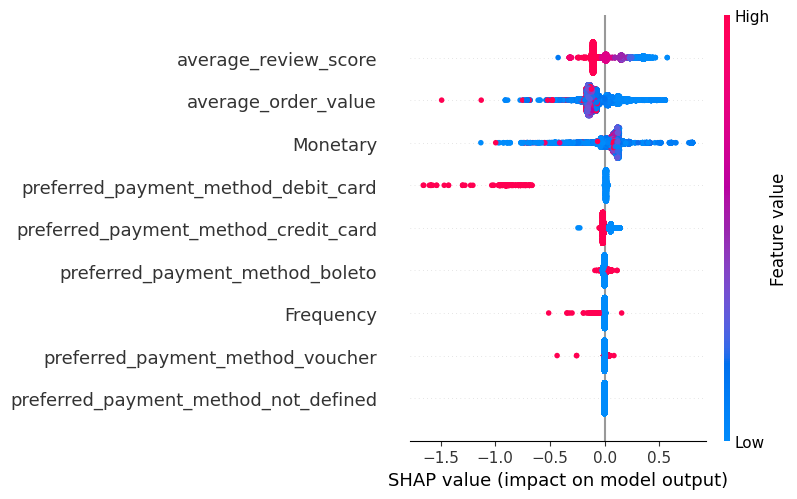

In [21]:
# ==========================================================
# SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=transformed_feature_names,
    show=True
)

In [22]:
# ==========================================================
# HIGH-RISK CUSTOMER
# ==========================================================

test_probabilities = gb_pipeline.predict_proba(
    X_test
)[:, 1]

highest_risk_position = np.argmax(
    test_probabilities
)

highest_risk_probability = (
    test_probabilities[highest_risk_position]
)

highest_risk_customer = X_test.iloc[
    highest_risk_position
]

print("=" * 60)
print("HIGHEST-RISK CUSTOMER PROFILE")
print("=" * 60)

print("\nRisk Probability:")
print(round(highest_risk_probability, 4))

print("\nCustomer Features:")
print(highest_risk_customer)

HIGHEST-RISK CUSTOMER PROFILE

Risk Probability:
0.8991

Customer Features:
Frequency                        1
Monetary                     77.57
average_review_score           1.0
preferred_payment_method    boleto
average_order_value          77.57
Name: 84511, dtype: object


In [23]:
# ==========================================================
# CUSTOMER-LEVEL SHAP EXPLANATION
# ==========================================================

customer_shap_values = shap_values[
    highest_risk_position
]

customer_explanation = pd.DataFrame({
    "Feature": transformed_feature_names,
    "SHAP_Value": customer_shap_values
})

customer_explanation[
    "Absolute_SHAP"
] = customer_explanation[
    "SHAP_Value"
].abs()

customer_explanation = (
    customer_explanation
    .sort_values(
        by="Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("HIGH-RISK CUSTOMER EXPLANATION")
print("=" * 60)

print(customer_explanation)

HIGH-RISK CUSTOMER EXPLANATION
                                Feature  SHAP_Value  Absolute_SHAP
0                              Monetary    0.770635       0.770635
1                  average_review_score    0.351590       0.351590
2                   average_order_value    0.054546       0.054546
3       preferred_payment_method_boleto    0.041683       0.041683
4  preferred_payment_method_credit_card    0.039482       0.039482
5   preferred_payment_method_debit_card    0.013541       0.013541
6                             Frequency    0.001813       0.001813
7      preferred_payment_method_voucher    0.000253       0.000253
8  preferred_payment_method_not_defined    0.000000       0.000000


In [24]:
# ==========================================================
# TOP RISK DRIVERS
# ==========================================================

top_risk_drivers = (
    customer_explanation[
        customer_explanation["SHAP_Value"] > 0
    ]
    .head(5)
)

print("=" * 60)
print("TOP FACTORS INCREASING CHURN-RISK")
print("=" * 60)

print(top_risk_drivers[
    ["Feature", "SHAP_Value"]
])

TOP FACTORS INCREASING CHURN-RISK
                                Feature  SHAP_Value
0                              Monetary    0.770635
1                  average_review_score    0.351590
2                   average_order_value    0.054546
3       preferred_payment_method_boleto    0.041683
4  preferred_payment_method_credit_card    0.039482


In [25]:
# ==========================================================
# TOP PROTECTIVE FACTORS
# ==========================================================

protective_factors = (
    customer_explanation[
        customer_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        by="SHAP_Value",
        ascending=True
    )
    .head(5)
)

print("=" * 60)
print("TOP FACTORS REDUCING CHURN-RISK")
print("=" * 60)

print(protective_factors[
    ["Feature", "SHAP_Value"]
])

TOP FACTORS REDUCING CHURN-RISK
Empty DataFrame
Columns: [Feature, SHAP_Value]
Index: []


In [26]:
# ==========================================================
# BUSINESS-FRIENDLY RISK EXPLANATION
# ==========================================================

print("=" * 60)
print("CUSTOMER RISK EXPLANATION")
print("=" * 60)

print(
    f"\nPredicted Churn-Risk Probability: "
    f"{highest_risk_probability:.2%}"
)

print("\nPrimary Risk Drivers:")

for _, row in top_risk_drivers.iterrows():

    print(
        f"- {row['Feature']}: "
        f"positive SHAP contribution "
        f"({row['SHAP_Value']:.4f})"
    )

print("\nProtective Factors:")

for _, row in protective_factors.iterrows():

    print(
        f"- {row['Feature']}: "
        f"negative SHAP contribution "
        f"({row['SHAP_Value']:.4f})"
    )

CUSTOMER RISK EXPLANATION

Predicted Churn-Risk Probability: 89.91%

Primary Risk Drivers:
- Monetary: positive SHAP contribution (0.7706)
- average_review_score: positive SHAP contribution (0.3516)
- average_order_value: positive SHAP contribution (0.0545)
- preferred_payment_method_boleto: positive SHAP contribution (0.0417)
- preferred_payment_method_credit_card: positive SHAP contribution (0.0395)

Protective Factors:
